# 3. Modelling

EEEM075 - AI and Sustainability coursework

Trains Model 1 (MLP, PyTorch) and Model 2 (XGBoost) to predict **NOX** from the ambient/operational sensors. `CO` is deliberately **not** used as a feature - the whole point of the soft sensor is to infer emissions from cheap process sensors, not from another pollutant reading, so using CO to predict NOX would defeat the purpose (and leak target-adjacent information).

Order of operations in this notebook:
1. **Feature-set selection** - the two engineered candidates from Notebook 1 (`TDROP`, `PRATIO`) are kept only if they improve validation RMSE; the decision is recorded in `artifacts/features.json`.
2. **Baselines** - both models with reasonable default hyperparameters, end-to-end.
3. **Hyperparameter tuning** - a validation-based search for each model.
4. **Training diagnostics** - loss curves for the tuned MLP to check over/underfitting directly.

In [17]:
import time
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

import xgboost as xgb

import matplotlib.pyplot as plt

ARTIFACT_DIR = Path('../artifacts')
MODEL_DIR = ARTIFACT_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

BASE_FEATURES = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']
ENGINEERED = ['TDROP', 'PRATIO']  # created in Notebook 1, kept only if they earn their place (below)
TARGET = 'NOX'

In [18]:
train = pd.read_csv(ARTIFACT_DIR / 'train.csv')
val = pd.read_csv(ARTIFACT_DIR / 'val.csv')
test = pd.read_csv(ARTIFACT_DIR / 'test.csv')

y_train, y_val, y_test = train[TARGET].values, val[TARGET].values, test[TARGET].values
print('Train:', train.shape, ' Val:', val.shape, ' Test:', test.shape)

Train: (22191, 14)  Val: (7158, 14)  Test: (7384, 14)


## A shared evaluation helper

Both models get scored with the same function, so results are directly comparable now, after tuning, and after compression in Notebook 5.

In [19]:
def evaluate(y_true, y_pred, label):
    # np.sqrt(mse) instead of squared=False for compatibility across sklearn versions
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label:>20} | RMSE: {rmse:.3f}  MAE: {mae:.3f}  R2: {r2:.3f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

## Model definitions and training functions

Both training routines take their data as arguments (rather than reading globals), so the same code drives the feature-set comparison, the baselines, and every tuning trial.

The MLP is a small feed-forward network with ReLU activations and dropout, trained with early stopping on validation loss. XGBoost trains on **unscaled** features (tree splits are scale-invariant); the MLP gets standardised features - this asymmetry is exactly the point made in the EDA notebook about feature scales.

In [20]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden=(64, 32), dropout=0.1):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def to_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_mlp(X_tr, y_tr, X_v, y_v, hidden=(64, 32), dropout=0.1, lr=1e-3, weight_decay=0.0,
              epochs=50, patience=8, batch_size=256, verbose=False, label=None):
    """Trains one MLP configuration with early stopping on validation loss.
    Returns (model, history, val_metrics, train_time_s).
    A single function drives the feature-set comparison, the baseline, and every tuning trial,
    so all MLP results are produced by identical training logic."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(SEED)

    train_loader = to_loader(X_tr, y_tr, batch_size=batch_size, shuffle=True)

    model = MLP(n_features=X_tr.shape[1], hidden=hidden, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    X_v_t = torch.tensor(X_v, dtype=torch.float32).to(device)
    y_v_t = torch.tensor(y_v, dtype=torch.float32).to(device)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(xb)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_v_t), y_v_t).item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f'  epoch {epoch:3d} | train_loss {train_loss:.3f} | val_loss {val_loss:.3f}')

        if epochs_no_improve >= patience:
            if verbose:
                print(f'  early stopping at epoch {epoch}')
            break

    train_time = time.time() - t0
    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_v_t).cpu().numpy()
    val_metrics = evaluate(y_v, val_pred, label or f'MLP {hidden} do={dropout} lr={lr}')

    return model, history, val_metrics, train_time


def train_xgb(params, X_tr, y_tr, X_v, y_v, label='XGBoost'):
    """Trains one XGBoost configuration. Returns (model, val_metrics, train_time_s)."""
    model = xgb.XGBRegressor(random_state=SEED, n_jobs=-1, **params)
    t0 = time.time()
    model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    train_time = time.time() - t0
    val_pred = model.predict(X_v)
    val_metrics = evaluate(y_v, val_pred, label)
    return model, val_metrics, train_time

## Feature-set selection: do the engineered features earn their place?

Both baseline models are trained twice - once on the 9 raw sensors, once with `TDROP` and `PRATIO` added - and compared on validation RMSE. **Decision rule (fixed before looking at the results):** the engineered features are kept only if they reduce the *average* validation RMSE across the two models; otherwise the base set is retained. The decision is saved to `artifacts/features.json`; as shown below, the engineered features were rejected, so the later notebooks work with the nine base sensors.

Rejection is informative in itself: it indicates that the raw sensors already carry that information (unsurprising for `TDROP`, which is a linear combination of two existing inputs, though the MLP could in principle benefit from having it pre-computed; `PRATIO` is a genuinely non-linear combination).

In [21]:
xgb_baseline_params = dict(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8)

candidate_sets = {
    'base (9 sensors)': BASE_FEATURES,
    'base + engineered (11)': BASE_FEATURES + ENGINEERED,
}

selection_rows = {}
for name, feats in candidate_sets.items():
    print(f'=== {name} ===')
    X_tr, X_v = train[feats].values, val[feats].values

    # MLP needs scaling; fit on train only
    sc = StandardScaler().fit(X_tr)
    _, _, mlp_m, _ = train_mlp(sc.transform(X_tr), y_train, sc.transform(X_v), y_val, label=f'MLP [{name}]')
    _, xgb_m, _ = train_xgb(xgb_baseline_params, X_tr, y_tr=y_train, X_v=X_v, y_v=y_val, label=f'XGB [{name}]')

    selection_rows[name] = {'mlp_rmse': mlp_m['rmse'], 'xgb_rmse': xgb_m['rmse'],
                            'avg_rmse': (mlp_m['rmse'] + xgb_m['rmse']) / 2}

selection_df = pd.DataFrame(selection_rows).T
print()
print(selection_df)

=== base (9 sensors) ===
MLP [base (9 sensors)] | RMSE: 9.423  MAE: 7.337  R2: 0.107
XGB [base (9 sensors)] | RMSE: 10.491  MAE: 9.126  R2: -0.107
=== base + engineered (11) ===
MLP [base + engineered (11)] | RMSE: 9.652  MAE: 7.699  R2: 0.063
XGB [base + engineered (11)] | RMSE: 10.651  MAE: 9.272  R2: -0.141

                        mlp_rmse   xgb_rmse   avg_rmse
base (9 sensors)        9.422852  10.491409   9.957130
base + engineered (11)  9.651550  10.651119  10.151335


In [22]:
if selection_df.loc['base + engineered (11)', 'avg_rmse'] < selection_df.loc['base (9 sensors)', 'avg_rmse']:
    FEATURES = BASE_FEATURES + ENGINEERED
    decision = 'KEPT — engineered features reduced average validation RMSE'
else:
    FEATURES = BASE_FEATURES
    decision = 'REJECTED — engineered features did not reduce average validation RMSE; base sensors already carry the information'

print('Decision:', decision)
print('Final feature list:', FEATURES)

with open(ARTIFACT_DIR / 'features.json', 'w') as f:
    json.dump({'features': FEATURES, 'decision': decision}, f, indent=2)
selection_df.to_csv(ARTIFACT_DIR / 'feature_selection_results.csv')

Decision: REJECTED — engineered features did not reduce average validation RMSE; base sensors already carry the information
Final feature list: ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']


## Final feature matrices and scaling (MLP only)

The scaler is fit on the **training set only** and then applied to val/test - fitting on the full dataset would leak information about the validation/test distribution into preprocessing. XGBoost uses the unscaled features directly.

In [23]:
X_train, X_val, X_test = train[FEATURES].values, val[FEATURES].values, test[FEATURES].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, MODEL_DIR / 'scaler.joblib')
print('Feature matrices built with', len(FEATURES), 'features; scaler saved.')

Feature matrices built with 9 features; scaler saved.


## Baselines (untuned)

Both models with reasonable defaults, on the selected feature set. Both baselines are weak: the MLP reaches a validation R² of only ~0.11 and XGBoost's is negative (~-0.11), i.e. worse than predicting the mean. This reflects the year-to-year drift seen in the EDA - a default, untuned XGBoost fits the exact patterns of 2011-2013 tightly and transfers poorly to 2014, while the MLP degrades less because dropout regularises it. The tuning below targets exactly this gap.

In [24]:
mlp_baseline, mlp_baseline_history, mlp_baseline_val_metrics, mlp_baseline_train_time = train_mlp(
    X_train_scaled, y_train, X_val_scaled, y_val, verbose=True)
print(f'MLP baseline training time: {mlp_baseline_train_time:.1f}s')

  epoch   0 | train_loss 4246.595 | val_loss 2256.788
  epoch   5 | train_loss 151.104 | val_loss 148.371
  epoch  10 | train_loss 91.663 | val_loss 120.633
  epoch  15 | train_loss 76.940 | val_loss 104.789
  epoch  20 | train_loss 72.469 | val_loss 98.778
  epoch  25 | train_loss 69.085 | val_loss 94.445
  epoch  30 | train_loss 67.637 | val_loss 97.983
  epoch  35 | train_loss 66.422 | val_loss 101.409
  early stopping at epoch 35
MLP (64, 32) do=0.1 lr=0.001 | RMSE: 9.423  MAE: 7.337  R2: 0.107
MLP baseline training time: 39.2s


In [25]:
xgb_baseline, xgb_baseline_val_metrics, xgb_baseline_train_time = train_xgb(
    xgb_baseline_params, X_train, y_train, X_val, y_val)
print(f'XGBoost baseline training time: {xgb_baseline_train_time:.1f}s')

             XGBoost | RMSE: 10.491  MAE: 9.126  R2: -0.107
XGBoost baseline training time: 2.2s


In [26]:
baseline_results = pd.DataFrame({
    'MLP': {**mlp_baseline_val_metrics, 'train_time_s': mlp_baseline_train_time},
    'XGBoost': {**xgb_baseline_val_metrics, 'train_time_s': xgb_baseline_train_time},
}).T

print(baseline_results)
baseline_results.to_csv(ARTIFACT_DIR / 'baseline_val_results.csv')

              rmse       mae        r2  train_time_s
MLP       9.422852  7.337371  0.106932     39.234548
XGBoost  10.491409  9.126497 -0.107101      2.201784


## Hyperparameter tuning

**Method:** a validation-based random search for each model - not k-fold cross-validation, because the data is time-ordered and shuffling into folds would let training data from the future leak into validation. Instead, every candidate configuration is trained on 2011-2013 and scored once on the fixed 2014 validation set, and the configuration with the lowest validation RMSE is kept. The test set (2015) is never touched during this search.

**Search ranges used:**

- **XGBoost:** `max_depth` in [2, 3, 4, 5, 6], `learning_rate` in [0.01, 0.03, 0.05, 0.1], `n_estimators` in [100, 200, 300, 500], `subsample` in [0.6, 0.8, 1.0], `colsample_bytree` in [0.6, 0.8, 1.0], `reg_alpha` in [0, 0.1, 1.0], `reg_lambda` in [1.0, 5.0, 10.0]. Shallower trees and stronger regularisation are included specifically to address the overfitting-to-train seen in the baseline.
- **MLP:** a hand-picked set of architectures/dropout/learning-rate/weight-decay combinations, ranging from a smaller, more regularised network up to a larger one, to see whether capacity or regularisation is the bottleneck.

**Selection criterion:** lowest validation RMSE. The number of trials is kept modest (~20 for XGBoost, ~6 for the MLP) given the CPU-only setup, which limits how much of the search space can be explored.

In [27]:
xgb_param_space = {
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0],
}

N_XGB_TRIALS = 20
xgb_trials = []

for i in range(N_XGB_TRIALS):
    params = {k: random.choice(v) for k, v in xgb_param_space.items()}
    _, val_metrics, train_time = train_xgb(params, X_train, y_train, X_val, y_val)
    xgb_trials.append({**params, **val_metrics, 'train_time_s': train_time})
    print(f'trial {i:2d}/{N_XGB_TRIALS} | rmse={val_metrics["rmse"]:.3f} | r2={val_metrics["r2"]:.3f} | {params}')

xgb_trials_df = pd.DataFrame(xgb_trials).sort_values('rmse').reset_index(drop=True)
xgb_trials_df.to_csv(ARTIFACT_DIR / 'xgb_tuning_trials.csv', index=False)
xgb_trials_df.head(5)

             XGBoost | RMSE: 11.413  MAE: 10.334  R2: -0.310
trial  0/20 | rmse=11.413 | r2=-0.310 | {'max_depth': 2, 'learning_rate': 0.01, 'n_estimators': 300, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_alpha': 0, 'reg_lambda': 10.0}
             XGBoost | RMSE: 11.287  MAE: 10.159  R2: -0.281
trial  1/20 | rmse=11.287 | r2=-0.281 | {'max_depth': 2, 'learning_rate': 0.01, 'n_estimators': 500, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_alpha': 0, 'reg_lambda': 1.0}
             XGBoost | RMSE: 11.072  MAE: 10.039  R2: -0.233
trial  2/20 | rmse=11.072 | r2=-0.233 | {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 1.0, 'reg_lambda': 10.0}
             XGBoost | RMSE: 10.436  MAE: 9.113  R2: -0.095
trial  3/20 | rmse=10.436 | r2=-0.095 | {'max_depth': 5, 'learning_rate': 0.03, 'n_estimators': 500, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0, 'reg_lambda': 1.0}
             XGBoost | RMSE: 10.396  

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,reg_alpha,reg_lambda,rmse,mae,r2,train_time_s
0,6,0.05,300,0.6,0.8,0.1,1.0,10.345047,9.010706,-0.076427,2.168325
1,6,0.05,500,1.0,0.8,0.1,1.0,10.349595,8.946020,-0.077374,3.535132
2,6,0.05,200,1.0,0.6,0.0,10.0,10.364476,9.136856,-0.080474,1.431935
3,5,0.03,300,0.6,0.6,1.0,10.0,10.376807,9.170549,-0.083047,2.077425
4,5,0.05,300,0.6,0.6,0.1,1.0,10.396266,9.033592,-0.087112,2.901702


In [28]:
best_xgb_params = xgb_trials_df.loc[0, list(xgb_param_space.keys())].to_dict()
# cast numeric types back (they may have become float via the DataFrame roundtrip)
for k in ['max_depth', 'n_estimators']:
    best_xgb_params[k] = int(best_xgb_params[k])

print('Best XGBoost params:', best_xgb_params)

xgb_tuned, xgb_tuned_val_metrics, xgb_tuned_train_time = train_xgb(best_xgb_params, X_train, y_train, X_val, y_val)
xgb_tuned.save_model(str(MODEL_DIR / 'xgb_tuned.json'))
with open(MODEL_DIR / 'xgb_tuned_params.json', 'w') as f:
    json.dump(best_xgb_params, f, indent=2)

Best XGBoost params: {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.6, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
             XGBoost | RMSE: 10.345  MAE: 9.011  R2: -0.076


In [29]:
mlp_param_space = [
    {'hidden': (32,),          'dropout': 0.0, 'lr': 1e-3, 'weight_decay': 0.0},
    {'hidden': (64, 32),       'dropout': 0.1, 'lr': 1e-3, 'weight_decay': 0.0},
    {'hidden': (64, 32),       'dropout': 0.2, 'lr': 1e-3, 'weight_decay': 1e-4},
    {'hidden': (32, 16),       'dropout': 0.2, 'lr': 1e-3, 'weight_decay': 1e-3},
    {'hidden': (128, 64, 32),  'dropout': 0.3, 'lr': 5e-4, 'weight_decay': 1e-4},
    {'hidden': (16,),          'dropout': 0.1, 'lr': 1e-3, 'weight_decay': 1e-3},
]

mlp_trials = []
mlp_trial_models = []
mlp_trial_histories = []

for i, params in enumerate(mlp_param_space):
    print(f'--- MLP trial {i}: {params} ---')
    model, history, val_metrics, train_time = train_mlp(X_train_scaled, y_train, X_val_scaled, y_val, **params, verbose=False)
    mlp_trials.append({**{k: str(v) for k, v in params.items()}, **val_metrics, 'train_time_s': train_time})
    mlp_trial_models.append(model)
    mlp_trial_histories.append(history)

mlp_trials_df = pd.DataFrame(mlp_trials).sort_values('rmse').reset_index(drop=True)
mlp_trials_df.to_csv(ARTIFACT_DIR / 'mlp_tuning_trials.csv', index=False)
mlp_trials_df

--- MLP trial 0: {'hidden': (32,), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0} ---
MLP (32,) do=0.0 lr=0.001 | RMSE: 11.785  MAE: 9.384  R2: -0.397
--- MLP trial 1: {'hidden': (64, 32), 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0} ---
MLP (64, 32) do=0.1 lr=0.001 | RMSE: 9.423  MAE: 7.337  R2: 0.107
--- MLP trial 2: {'hidden': (64, 32), 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001} ---
MLP (64, 32) do=0.2 lr=0.001 | RMSE: 9.004  MAE: 6.993  R2: 0.185
--- MLP trial 3: {'hidden': (32, 16), 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.001} ---
MLP (32, 16) do=0.2 lr=0.001 | RMSE: 8.493  MAE: 6.693  R2: 0.274
--- MLP trial 4: {'hidden': (128, 64, 32), 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001} ---
MLP (128, 64, 32) do=0.3 lr=0.0005 | RMSE: 8.212  MAE: 6.148  R2: 0.322
--- MLP trial 5: {'hidden': (16,), 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.001} ---
MLP (16,) do=0.1 lr=0.001 | RMSE: 11.140  MAE: 8.673  R2: -0.248


,hidden,dropout,lr,weight_decay,rmse,mae,r2,train_time_s
0,"(128, 64, 32)",0.3,0.0005,0.0001,8.211858,6.148217,0.321730,35.450431
1,"(32, 16)",0.2,0.001,0.001,8.493001,6.692562,0.274492,46.368819
2,"(64, 32)",0.2,0.001,0.0001,9.003768,6.993125,0.184604,34.338174
3,"(64, 32)",0.1,0.001,0.0,9.422852,7.337371,0.106932,27.295385
4,"(16,)",0.1,0.001,0.001,11.139883,8.673441,-0.248191,29.443384
5,"(32,)",0.0,0.001,0.0,11.784741,9.383520,-0.396882,48.908682


In [30]:
best_mlp_idx = pd.DataFrame(mlp_trials)['rmse'].idxmin()
best_mlp_params = mlp_param_space[best_mlp_idx]
mlp_tuned = mlp_trial_models[best_mlp_idx]
mlp_tuned_val_metrics = mlp_trials[best_mlp_idx]
mlp_tuned_history = mlp_trial_histories[best_mlp_idx]

print('Best MLP params:', best_mlp_params)

torch.save(mlp_tuned.state_dict(), MODEL_DIR / 'mlp_tuned.pt')
with open(MODEL_DIR / 'mlp_tuned_params.json', 'w') as f:
    json.dump({k: (list(v) if isinstance(v, tuple) else v) for k, v in best_mlp_params.items()}, f, indent=2)

Best MLP params: {'hidden': (128, 64, 32), 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001}


## Training diagnostics - loss curves for the tuned MLP

Direct visual evidence of the over/underfitting behaviour: training loss vs validation loss per epoch for the selected configuration. What to look for - validation loss tracking training loss down and flattening (healthy fit with early stopping doing its job), versus validation loss turning upward while training loss keeps falling (overfitting, which the early-stopping patience is there to catch). The persistent gap between the two curves reflects the 2013→2014 distribution shift documented in the EDA, not just variance: the validation year is genuinely harder than held-in training data.

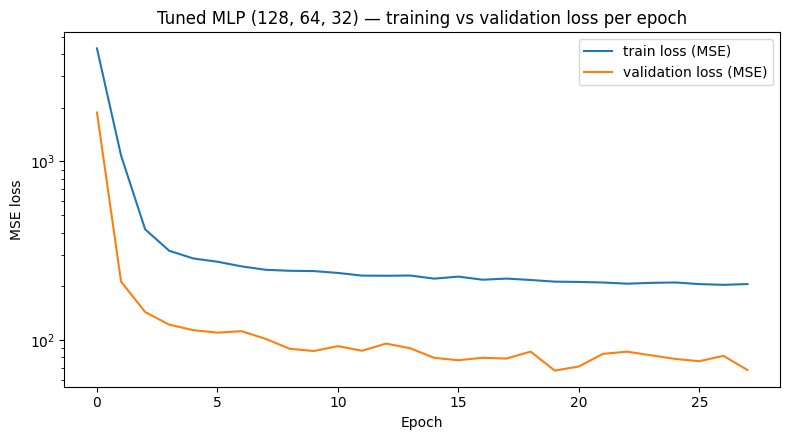

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
epochs_ran = range(len(mlp_tuned_history['train_loss']))
ax.plot(epochs_ran, mlp_tuned_history['train_loss'], label='train loss (MSE)')
ax.plot(epochs_ran, mlp_tuned_history['val_loss'], label='validation loss (MSE)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_yscale('log')
ax.set_title(f'Tuned MLP {best_mlp_params["hidden"]} — training vs validation loss per epoch')
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / 'fig_mlp_loss_curves.png', dpi=150, bbox_inches='tight')

## Baseline vs. tuned comparison

In [32]:
comparison = pd.DataFrame({
    'MLP (baseline)': {**mlp_baseline_val_metrics, 'train_time_s': mlp_baseline_train_time},
    'MLP (tuned)': {'rmse': mlp_tuned_val_metrics['rmse'], 'mae': mlp_tuned_val_metrics['mae'], 'r2': mlp_tuned_val_metrics['r2'], 'train_time_s': mlp_tuned_val_metrics['train_time_s']},
    'XGBoost (baseline)': {**xgb_baseline_val_metrics, 'train_time_s': xgb_baseline_train_time},
    'XGBoost (tuned)': {**xgb_tuned_val_metrics, 'train_time_s': xgb_tuned_train_time},
}).T

print(comparison)
comparison.to_csv(ARTIFACT_DIR / 'tuned_val_results.csv')

                         rmse       mae        r2  train_time_s
MLP (baseline)       9.422852  7.337371  0.106932     39.234548
MLP (tuned)          8.211858  6.148217  0.321730     35.450431
XGBoost (baseline)  10.491409  9.126497 -0.107101      2.201784
XGBoost (tuned)     10.345047  9.010706 -0.076427      2.630602


**Note:** all numbers above are still on the **validation set** (2014) - used to select hyperparameters, never to report final performance. The held-out **test set (2015)** stays completely untouched until Notebook 4, where the tuned models are evaluated properly, compared for computational cost, and explained with SHAP.